In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from resample import fill_gaps_with_periodicity_adaptive

In [78]:
def plot_timeseries(df, value_columns, 
                   plot_type='line', 
                   date_range=None,
                   figsize=(15, 8),
                   title=None,
                   labels=None,
                   outliers=False):
    """
    Plots time series data from a single DataFrame with a 'timestamp' column.
    Each column is plotted as a separate line with the same style but different colors.

    Args:
        df (pd.DataFrame): DataFrame with time series data (must have 'timestamp' column)
        value_columns (str or list of str): Name(s) of the value column(s) to plot
        plot_type (str): 'line', 'scatter', 'both', or 'resampled'
        date_range (tuple): (start_date, end_date) to filter the data
        figsize (tuple): Figure size (width, height)
        title (str): Custom plot title
        labels (list): Custom labels for each column (if None, uses column names)
        outliers (bool): If True, highlight outliers with large dots (requires 'is_outlier' column)

    Returns:
        matplotlib.figure.Figure

    Examples:
        # Basic usage with multiple columns
        fig = plot_timeseries(df, ['Value1', 'Value2', 'Value3'])

        # With outliers highlighted
        fig = plot_timeseries(df, ['Diff'], plot_type='scatter', outliers=True)

        # Comparing different preprocessing results
        fig = plot_timeseries(df, ['Raw', 'Hourly', 'Interpolated'],
                             labels=['Raw', 'Hourly', 'Interpolated'],
                             title='Data Preprocessing Comparison',
                             outliers=True)
    """

    # Input validation
    if 'timestamp' not in df.columns:
        raise ValueError("DataFrame must have a 'timestamp' column")

    # Check for is_outlier column if outliers parameter is True
    if outliers and 'is_outlier' not in df.columns:
        raise ValueError("DataFrame must have an 'is_outlier' column to plot outliers")

    # Convert value_columns to list if it's a single string
    if isinstance(value_columns, str):
        value_columns = [value_columns]
    
    if not isinstance(value_columns, list):
        raise ValueError("value_columns must be a string or list of strings")

    if len(value_columns) == 0:
        raise ValueError("value_columns cannot be empty")

    # Check that all columns exist
    for col in value_columns:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' not found in DataFrame")

    # Default labels if not provided
    if labels is None:
        labels = value_columns
    elif len(labels) != len(value_columns):
        raise ValueError("Number of labels must match number of columns")

    # Color palette for different lines - use tab10 colormap for up to 10 distinct colors
    if len(value_columns) < 5:
        colors_line = plt.cm.tab10([0, 3, 6, 9])
        colors_scatter = plt.cm.tab10([1, 4, 7, 8])
    else:
        # For more than 10 columns, use a continuous colormap
        colors_line = plt.cm.viridis(np.linspace(0, 1, len(value_columns)))
        colors_scatter = colors_line  # Use same colors for scatter when many columns

    # Prepare DataFrame
    df_plot = df.copy()
    
    # Ensure timestamp column is datetime
    df_plot['timestamp'] = pd.to_datetime(df_plot['timestamp'])

    # Filter by date range
    if date_range:
        start_date, end_date = date_range
        df_plot = df_plot[(df_plot['timestamp'] >= start_date) & 
                         (df_plot['timestamp'] <= end_date)]
        print(f"Filtered to date range: {date_range}")

    print(f"Plotting {len(df_plot)} points across {len(value_columns)} columns")
    
    # Count outliers if enabled
    if outliers:
        outlier_count = df_plot['is_outlier'].sum()
        print(f"Found {outlier_count} outliers ({100*outlier_count/len(df_plot):.2f}%)")

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)

    if title is None:
        title = f"Time Series Plot ({len(df_plot):,} points)"

    # Plot each column
    for i, (col, label) in enumerate(zip(value_columns, labels)):
        # Skip if column has no valid data
        if df_plot[col].isna().all():
            print(f"Warning: Column '{col}' has no valid data")
            continue

        # Get appropriate colors
        color_line = colors_line[i]
        color_scatter = colors_scatter[i] if i < len(colors_scatter) else color_line

        # Plot types - all columns use same style but different colors
        if plot_type == 'line':
            ax.plot(df_plot['timestamp'], df_plot[col],
                    linewidth=1, alpha=1, color=color_line, label=label)

        elif plot_type == 'scatter':
            ax.scatter(df_plot['timestamp'], df_plot[col],
                       s=1, alpha=0.6, color=color_scatter, label=label)

        elif plot_type == 'both':
            ax.plot(df_plot['timestamp'], df_plot[col],
                    linewidth=0.8, alpha=0.8, color=color_line, label=f'{label} (Line)')
            ax.scatter(df_plot['timestamp'], df_plot[col],
                       s=5, alpha=0.6, color=color_scatter, label=f'{label} (Points)')

        elif plot_type == 'resampled':
            # For resampling, temporarily set timestamp as index
            df_temp = df_plot.set_index('timestamp')
            df_resampled = df_temp[col].resample('h').mean()
            ax.plot(df_resampled.index, df_resampled,
                    linewidth=1, color=color_line, label=f'{label} (Hourly Avg)')
            print(f"Column '{col}' resampled to hourly averages: {len(df_resampled)} points")

        # Plot outliers as large dots if enabled
        if outliers:
            df_outliers = df_plot[df_plot['is_outlier'] == True]
            if len(df_outliers) > 0:
                ax.scatter(df_outliers['timestamp'], df_outliers[col],
                          s=100, alpha=0.9, color=color_line, 
                          edgecolors='red', linewidths=2, 
                          marker='o', zorder=5, label=f'{label} (Outliers)')

    # Labels and formatting
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Enhanced stats box for multiple columns
    stats_lines = []
    for col, label in zip(value_columns, labels):
        valid_data = df_plot[col].dropna()
        if len(valid_data) > 0:
            stats_lines.append(f"{label}:")
            stats_lines.append(f"  Min: {valid_data.min():.2f}")
            stats_lines.append(f"  Max: {valid_data.max():.2f}")
            stats_lines.append(f"  Mean: {valid_data.mean():.2f}")
            stats_lines.append(f"  Std: {valid_data.std():.2f}")
            stats_lines.append(f"  Valid: {len(valid_data)}/{len(df_plot)}")
            if col != value_columns[-1]:  # Add separator except for last
                stats_lines.append("---")

    stats_text = "\n".join(stats_lines)

    # Adjust stats box font size based on number of columns
    font_size = max(8, min(10, 10 - len(value_columns) // 3))

    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round',
            facecolor='wheat', alpha=0.8), fontsize=font_size)

    plt.tight_layout()
    plt.show()
    # return fig


In [55]:
class LocalLinearTrendModel(sm.tsa.statespace.MLEModel):
    def __init__(self, endog):
        k_states = 2  # level and slope
        k_posdef = 2  # process noise for level and slope

        super().__init__(
            endog, k_states=k_states, k_posdef=k_posdef,
            initialization='approximate_diffuse',
            loglikelihood_burn=48*7
        )

        # Design matrix (maps state to observed y_t)
        self.ssm['design', 0, 0] = 1  

        # For transition:
        # State vector: [level, slope]
        # [level_t]   = [1  1] [level_{t-1}]
        # [slope_t]     [0  1] [slope_{t-1}]
        self.ssm['transition', 0, 0] = 1
        self.ssm['transition', 0, 1] = 1
        self.ssm['transition', 1, 1] = 1

        # Selection: which states get noise
        self.ssm['selection', 0, 0] = 1
        self.ssm['selection', 1, 1] = 1

    def update(self, params, *args, **kwargs):
        params = super().update(params, *args, **kwargs)
        # Observation noise
        self.ssm['obs_cov', 0, 0] = params[0]
        # State noise (for level and slope)
        self.ssm['state_cov', 0, 0] = params[1]
        self.ssm['state_cov', 1, 1] = params[2]

    @property
    def param_names(self):
        return ['sigma2.obs', 'sigma2.level', 'sigma2.slope']

    @property
    def start_params(self):
        return [np.nanstd(self.endog)] * 3

    def transform_params(self, params):
        # Constrain variances to be positive
        return np.square(params)

    def untransform_params(self, params):
        return np.sqrt(params)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from resample import fill_gaps_with_periodicity_adaptive

class LocalLevelWithFixedSlope(sm.tsa.statespace.MLEModel):
    def __init__(self, endog):
        k_states = 2  # level and slope
        k_posdef = 2  # process noise for level and slope

        super().__init__(
            endog, k_states=k_states, k_posdef=k_posdef,
            initialization='approximate_diffuse',
            loglikelihood_burn=48*7
        )
        self.ssm['design', 0, 0] = 1

        self.ssm['transition', 0, 0] = 1
        self.ssm['transition', 0, 1] = 1
        self.ssm['transition', 1, 1] = 1  # slope is deterministic

        self.ssm['selection', 0, 0] = 1
        self.ssm['selection', 1, 1] = 1

    def update(self, params, *args, **kwargs):
        params = super().update(params, *args, **kwargs)
        # Only estimate observation and level noise
        self.ssm['obs_cov', 0, 0] = params[0]
        self.ssm['state_cov', 0, 0] = params[1]
        # Slope noise is fixed to zero
        self.ssm['state_cov', 1, 1] = 0

    @property
    def param_names(self):
        return ['sigma2.obs', 'sigma2.level']  # Only two names

    @property
    def start_params(self):
        s = np.nanstd(self.endog)
        return [s, s]

    def transform_params(self, params):
        return np.square(params)

    def untransform_params(self, params):
        return np.sqrt(params)


In [57]:
df = pd.read_csv('./test/data/VAR_41494_55419-odecty.csv', sep=";")[['VAR_ID', 'Time of reading', 'Value', 'Diff.']]
df.rename(columns={'Diff.': 'Diff', 'Value':'hodnota', 'Time of reading':'timestamp', 'VAR_ID':'id'}, inplace=True)
df = df.iloc[::-1].reset_index(drop=True)
#df = pd.read_csv('./test/data/artificial_water_consumption_3months.csv')
df.head()

,id,timestamp,hodnota,Diff
0,55419,2024-08-29 00:14:56.0,789.73,NaN
1,55419,2024-08-29 00:44:56.0,789.73,0.0
2,55419,2024-08-29 01:14:56.0,789.73,0.0
3,55419,2024-08-29 01:44:56.0,789.73,0.0
4,55419,2024-08-29 02:14:56.0,789.73,0.0


In [58]:
df_filled, dia = fill_gaps_with_periodicity_adaptive(df, timestamp_col='timestamp')
print(dia)

{'total_expected_timestamps': 17553.727222222224, 'total_actual_readings': 17267, 'total_after_filling': 17554, 'total_matched_readings': 17265, 'missing_values_filled': 289, 'nan_diff_count': 316, 'unmatched_readings_count': 2, 'unmatched_readings_detail': [{'reading_timestamp': '2024-08-29 00:14:56+00:00', 'hodnota': 789.73, 'expected_slot': '2024-08-29 00:44:56+00:00', 'time_difference_seconds': 1800.0, 'prev_reading_timestamp': None, 'prev_reading_value': None, 'next_reading_timestamp': '2024-08-29 00:44:56+00:00', 'next_reading_value': 789.73}, {'reading_timestamp': '2024-10-27 02:13:34+00:00', 'hodnota': 801.91, 'expected_slot': '2024-10-27 02:13:35+00:00', 'time_difference_seconds': 1.0, 'prev_reading_timestamp': '2024-10-27 02:43:34+00:00', 'prev_reading_value': 801.91, 'next_reading_timestamp': '2024-10-27 03:13:34+00:00', 'next_reading_value': 801.91}], 'date_range': '2024-08-29 to 2025-08-29', 'periodicity_used_seconds': 1800.0, 'tolerance_percentage': 10, 'tolerance_used_se

In [59]:
df_filled.head()

,id,timestamp,hodnota,Diff
0,55419,2024-08-29 00:44:56+00:00,789.73,NaN
1,55419,2024-08-29 01:14:56+00:00,789.73,0.0
2,55419,2024-08-29 01:44:56+00:00,789.73,0.0
3,55419,2024-08-29 02:14:56+00:00,789.73,0.0
4,55419,2024-08-29 02:44:56+00:00,789.73,0.0


In [60]:
df_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17554 entries, 0 to 17553
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   id         17554 non-null  int64              
 1   timestamp  17554 non-null  datetime64[ns, UTC]
 2   hodnota    17265 non-null  float64            
 3   Diff       17238 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(2), int64(1)
memory usage: 548.7 KB


Plotting 17267 points across 1 columns


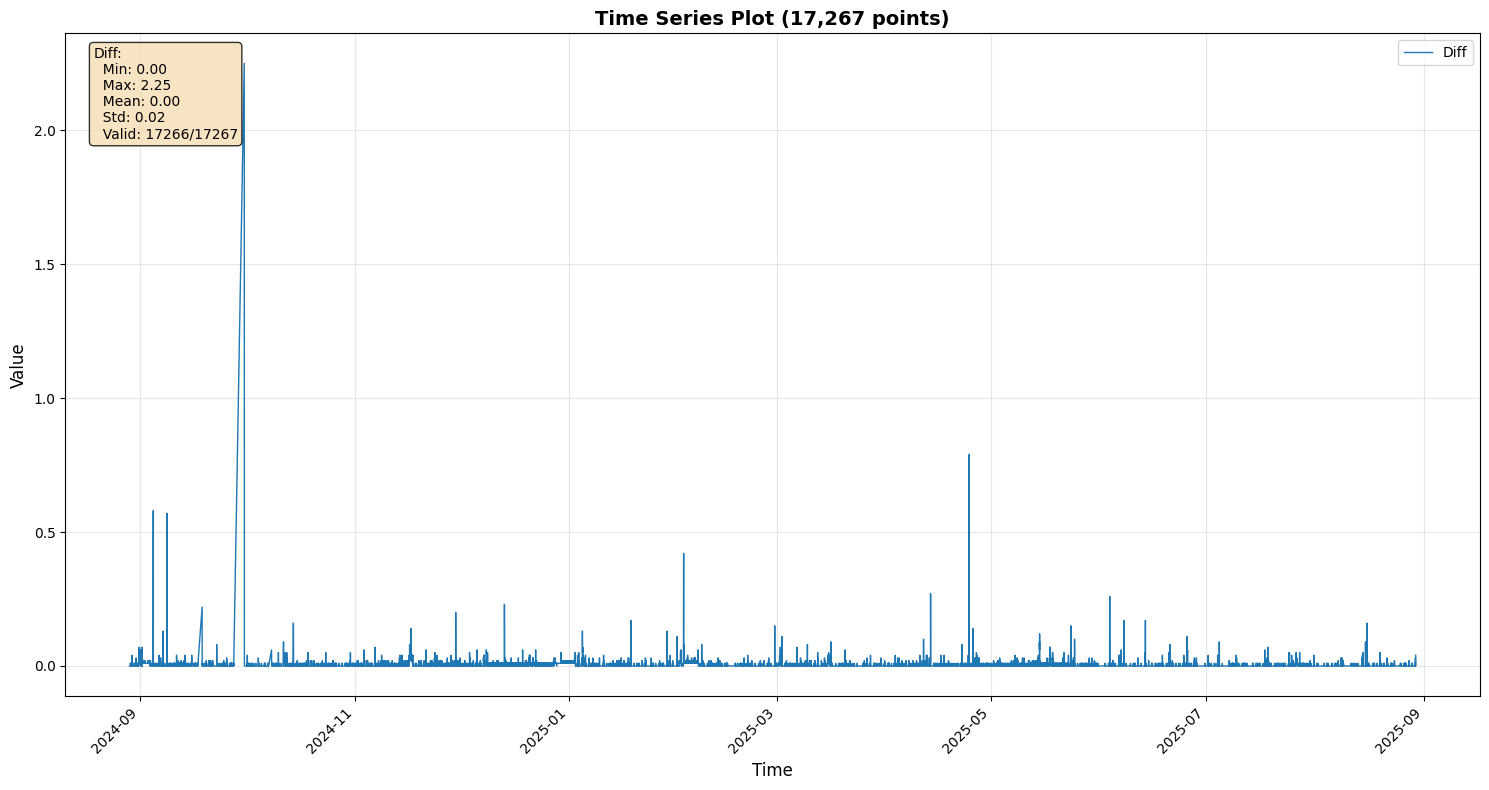

In [61]:
plot_timeseries(df, 'Diff')

Plotting 17554 points across 1 columns


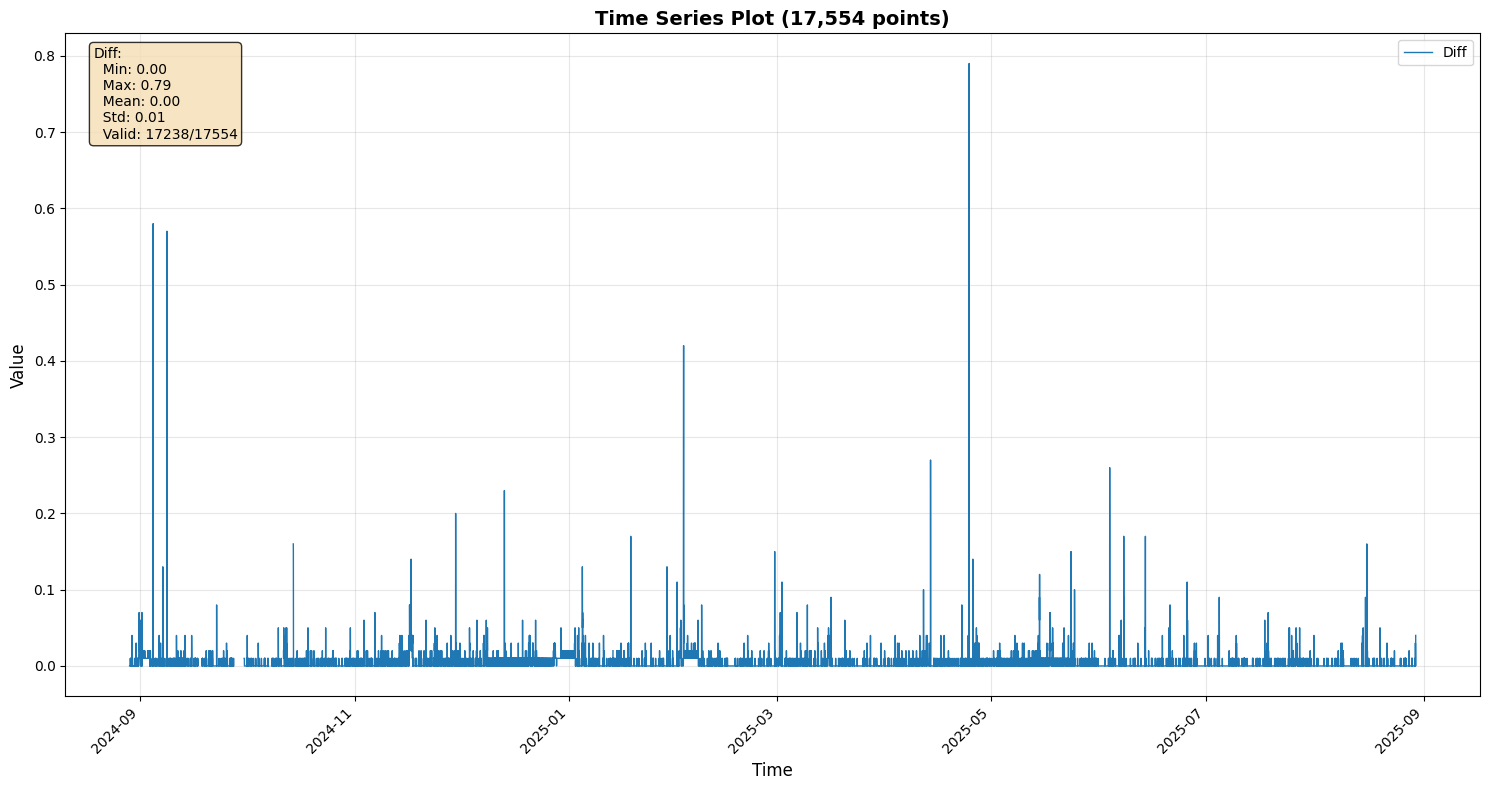

In [62]:
plot_timeseries(df_filled, 'Diff')

Filtered to date range: ('2025-04-23', '2025-04-26')
Plotting 144 points across 1 columns


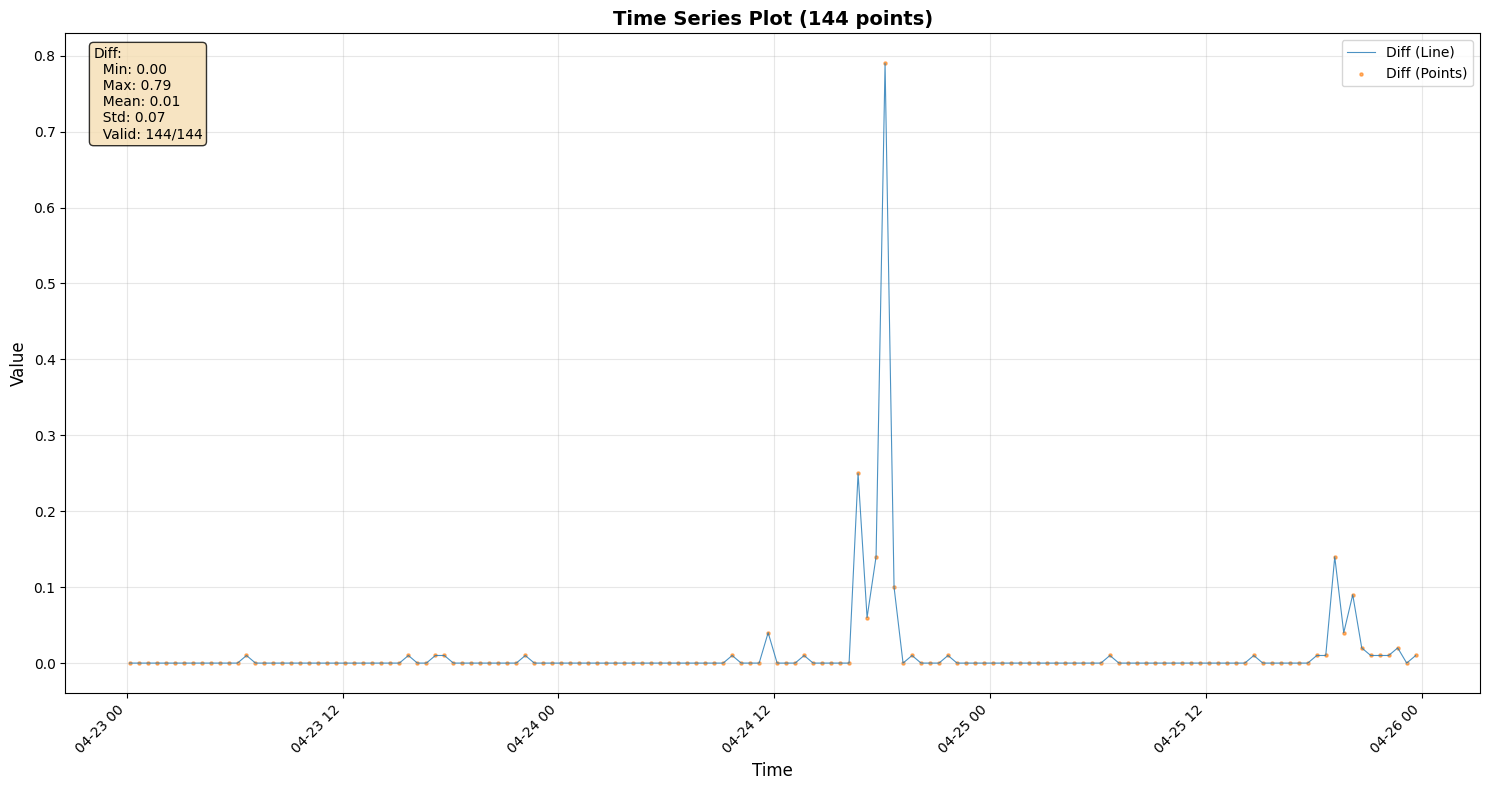

In [63]:
plot_timeseries(df_filled, 'Diff', date_range=('2025-04-23', '2025-04-26'), plot_type='both')

In [64]:
df_original = df.copy()
df = df_filled.copy()

In [65]:

#df = df[:2*30*48]
mod = LocalLevelWithFixedSlope(df['Diff'].values)
#mod = LocalLinearTrendModel(df['Diff'].values)
res = mod.fit()

predict = res.get_prediction()
df['Predicted Mean'] = predict.predicted_mean

print(res.mle_retvals)

{'fopt': -2.867083891746998, 'gopt': array([1.14352350e-04, 1.80013338e-05]), 'fcalls': 75, 'warnflag': 0, 'converged': True, 'iterations': 9}


In [66]:
print(res.summary())

                              Statespace Model Results                              
Dep. Variable:                            y   No. Observations:                17554
Model:             LocalLevelWithFixedSlope   Log Likelihood               50328.791
Date:                      Thu, 27 Nov 2025   AIC                        -100653.581
Time:                              20:31:42   BIC                        -100638.074
Sample:                                   0   HQIC                       -100648.471
                                    - 17554                                         
Covariance Type:                        opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
sigma2.obs       0.0001   1.38e-07    862.084      0.000       0.000       0.000
sigma2.level  7.145e-06   3.86e-08    185.210      0.000    7.07e-06    7.22e

Filtered to date range: ('2025-08-17', '2025-08-19')
Plotting 96 points across 2 columns


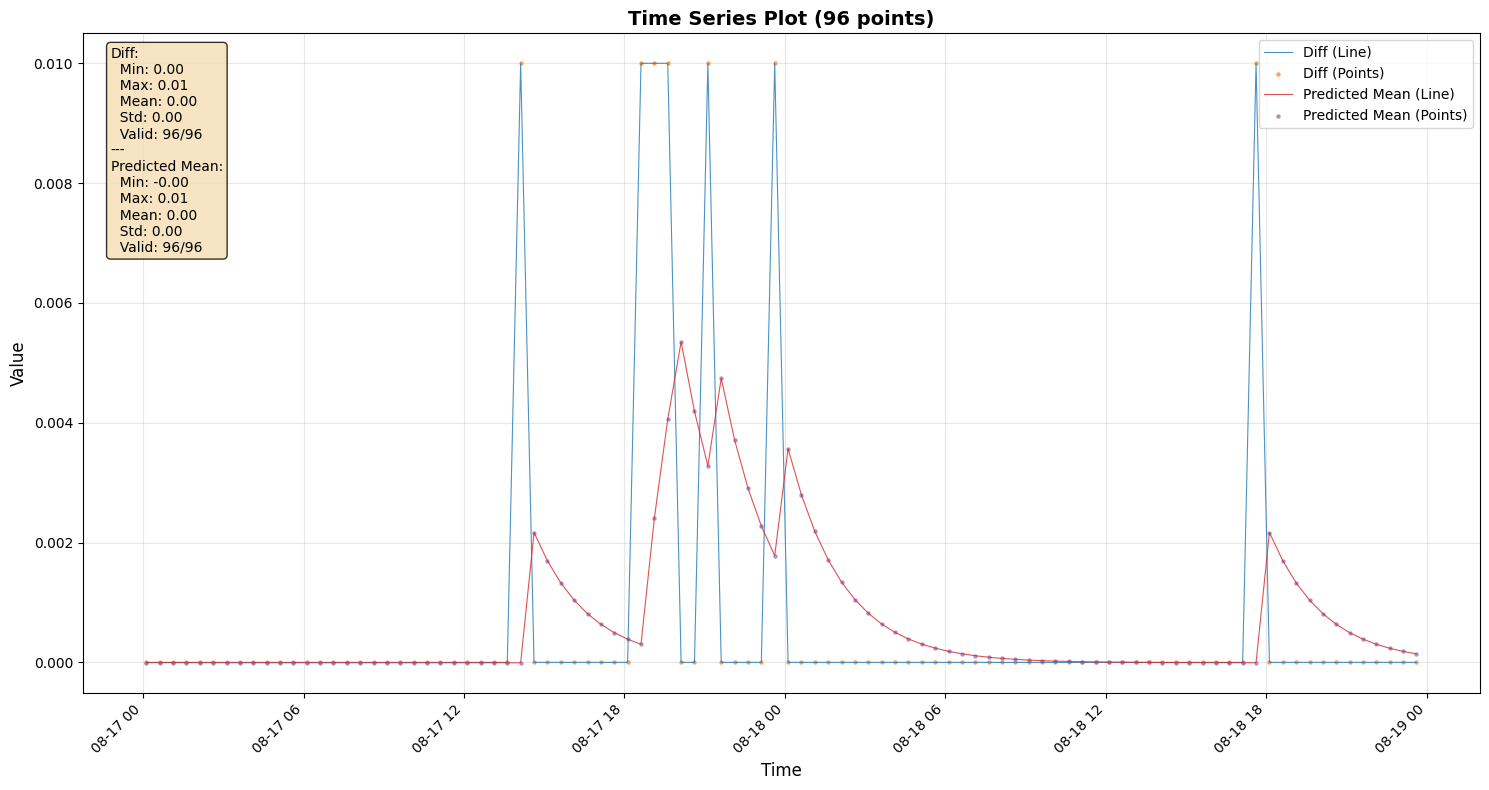

In [67]:
plot_timeseries(df, ['Diff', 'Predicted Mean'], plot_type='both', date_range=('2025-08-17', '2025-08-19'))

In [76]:
import numpy as np
import pandas as pd
from pyod.models.copod import COPOD
from pyod.models.gmm import GMM


df = df_original.copy().dropna()
timestamp_col = 'timestamp'

# 1. Prepare your data: Measurement + Timestamp
# Assume df has columns: ['timestamp', 'value']
df[timestamp_col] = pd.to_datetime(df[timestamp_col])
df['hour'] = df[timestamp_col].dt.hour + df[timestamp_col].dt.minute / 60

# 2. CRITICAL: Cyclical Encoding
# This tells the model that 23:59 is close to 00:01
df['time_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['time_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# 3. Create Feature Vector
# We feed the model the value AND the context (time)
X = df[['Diff', 'time_sin', 'time_cos']].values

# 4. Train Probabilistic Model (COPOD)
# COPOD learns the joint distribution of (Value, Time)
clf = COPOD(contamination=0.01)
clf.fit(X)

# 5. Get Probability of Outlier
# This "probability" considers the correlation. 
# High value at wrong time = High Outlier Score.
probs = clf.predict_proba(X)[:, 1]  # Probability of being an outlier
scores = clf.decision_function(X)   # Raw outlier scores

# 6. Add three new columns to dataframe
df['outlier_prob'] = probs
df['outlier_score'] = scores
df['is_outlier'] = probs > 0.80  # Boolean: True if probability > 0.95

# Example Output Interpretation
# A value of 100 at 12:00 (matches correlation) -> Low Score
# A value of 100 at 00:00 (breaks correlation) -> High Score

# Optional: Check how many outliers were detected
print(f"Total outliers detected: {df['is_outlier'].sum()} ({df['is_outlier'].mean()*100:.2f}%)")


Total outliers detected: 5 (0.03%)


Plotting 17266 points across 1 columns
Found 5 outliers (0.03%)


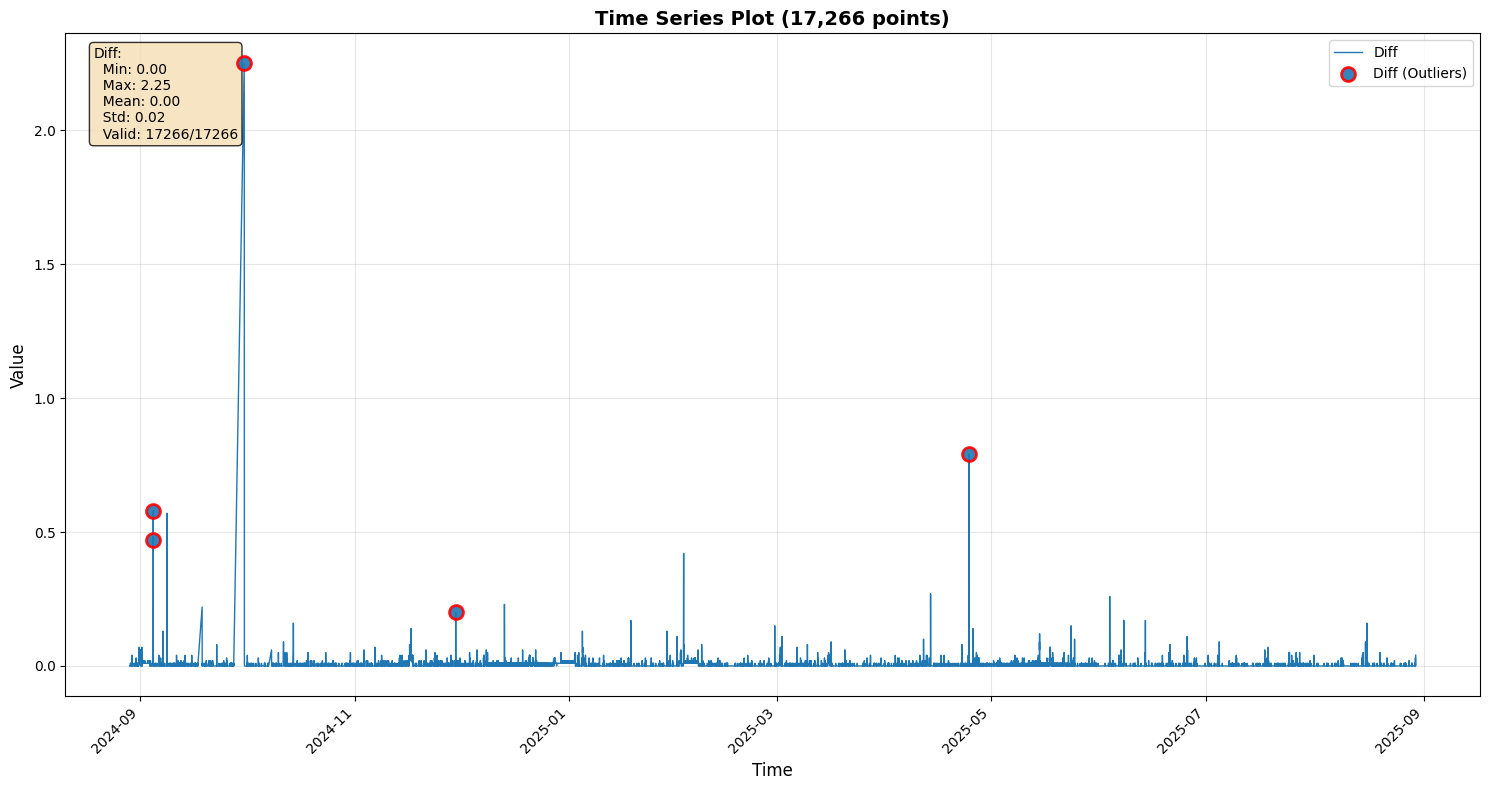

In [79]:
plot_timeseries(df, ["Diff"], outliers=True)

Filtered to date range: ('2024-12-22', '2025-01-02')
Plotting 527 points across 1 columns


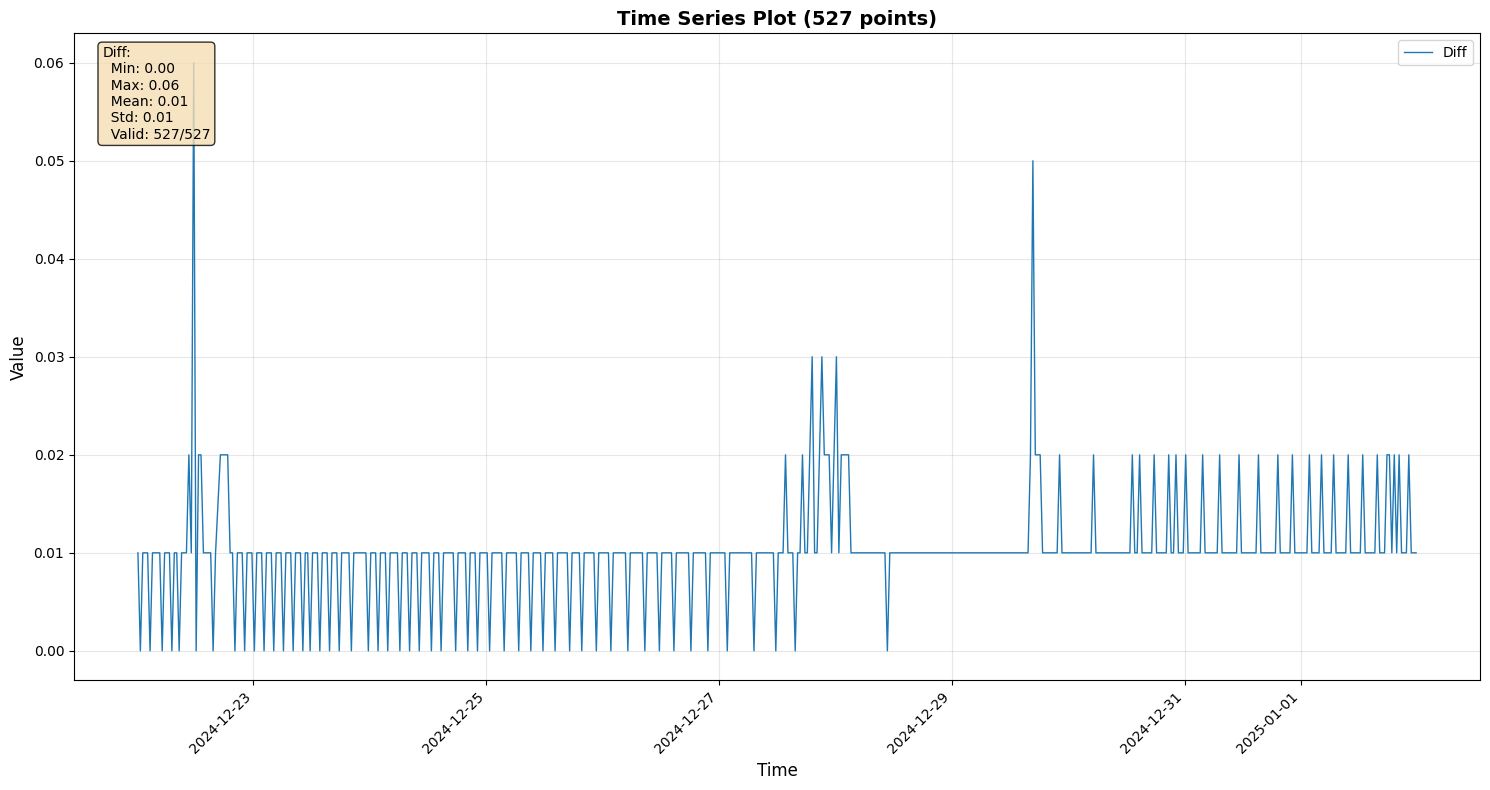

In [81]:
plot_timeseries(df, ["Diff"], date_range=('2024-12-22', '2025-01-02'))